In [4]:
# !pip install -e .[cplex]

In [5]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)

from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from qiskit.quantum_info.random import random_unitary
from gulps.cts_linear_program import ContinuousISAConstraints
import numpy as np
from tqdm import tqdm


def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()

In [6]:
base = GateInvariants.from_unitary(fsim(np.pi / 2, np.pi / 6).power(1.0))
solver = ContinuousISAConstraints(base=base, sequence_length=8, offset=1e-6)

In [7]:
print("=== sanity on k vars ===")
for i, v in enumerate(solver.k_vars):
    print(i, "LB=", v.lb, "UB=", v.ub, "type=", getattr(v, "vartype", None))


=== sanity on k vars ===
0 LB= 0.1 UB= 1.0 type= VarType_semi-continuous
1 LB= 0.1 UB= 1.0 type= VarType_semi-continuous
2 LB= 0.1 UB= 1.0 type= VarType_semi-continuous
3 LB= 0.1 UB= 1.0 type= VarType_semi-continuous
4 LB= 0.1 UB= 1.0 type= VarType_semi-continuous
5 LB= 0.1 UB= 1.0 type= VarType_semi-continuous
6 LB= 0.1 UB= 1.0 type= VarType_semi-continuous
7 LB= 0.1 UB= 1.0 type= VarType_semi-continuous


In [22]:
def cts_solve(solver, target):
    cost_f = None
    solver.set_target(target, rho_bool=False)
    gi_list, intermediates, ks = solver.solve()
    cost_f = sum(ks)

    solver.set_target(target, rho_bool=True)
    gi_list_rho, intermediates_rho, ks_rho = solver.solve()
    cost_f_rho = sum(ks_rho)
    if cost_f_rho < cost_f:
        return gi_list_rho, intermediates_rho, ks_rho
    return gi_list, intermediates, ks

[0.5486001385304905, 0.18695497036303765] 0.7355551088935282


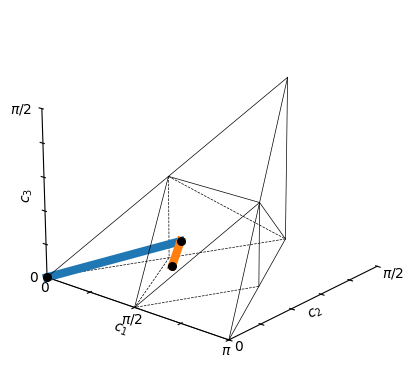

In [23]:
# target = GateInvariants.from_unitary(iSwapGate())
target = GateInvariants.from_unitary(random_unitary(dims=4))

gi_list, intermediates, ks = cts_solve(solver, target)
print(ks, sum(ks))

from gulps.utils.visualize import render_path

render_path(intermediates);

In [21]:
from gulps.gulps_decomposer import GulpsDecomposer

isa = [
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 7), 1 / 7, "sqrt7fsim"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(
    gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
)

[gulps.gulps_decomposer] DEBUG: lp falls back to opposite rho_reflect


0.7619047619047619


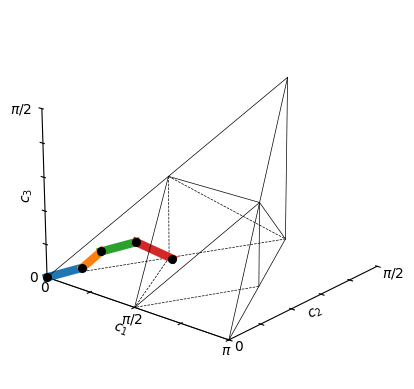

In [22]:
sentence_out, example_intermediates = decomposer._best_decomposition(target_inv=target)
print(sum(decomposer.isa.cost_dict[g] for g in sentence_out))
render_path(example_intermediates);

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [03:06<00:00, 53.59it/s]


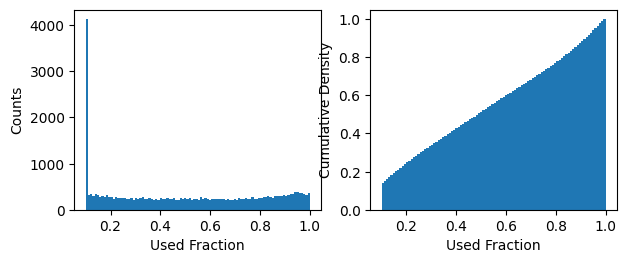

In [29]:
from qiskit.circuit.library import RXXGate

zz_base = GateInvariants.from_unitary(RXXGate(theta=np.pi / 2))
zz_solver = ContinuousISAConstraints(base=zz_base, sequence_length=8, offset=1e-6)
used_fractions = []
N = 10_000
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(zz_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [03:23<00:00, 49.25it/s]


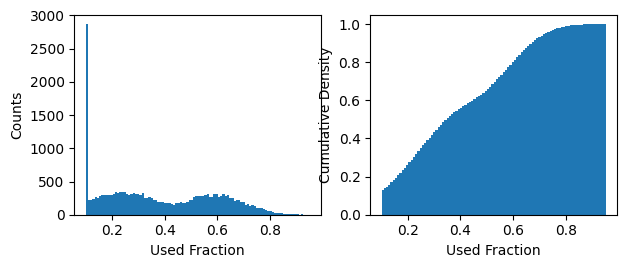

In [30]:
fsim_base = GateInvariants.from_unitary(fsim(np.pi / 2, np.pi / 6).power(1.0))
fsim_solver = ContinuousISAConstraints(base=fsim_base, sequence_length=8, offset=1e-5)

used_fractions = []
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(fsim_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

  0%|          | 6/10000 [00:00<03:05, 54.02it/s]

100%|██████████| 10000/10000 [03:00<00:00, 55.26it/s]


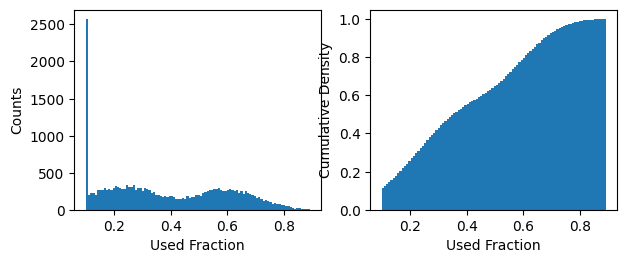

In [31]:
iswap_base = GateInvariants.from_unitary(iSwapGate().power(1.0))
iswap_solver = ContinuousISAConstraints(base=iswap_base, sequence_length=8, offset=1e-5)
used_fractions = []
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(iswap_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [03:08<00:00, 52.92it/s]


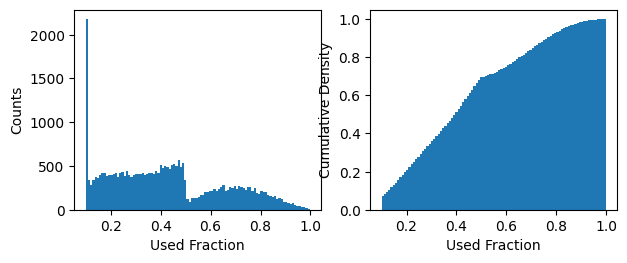

In [32]:
swap_base = GateInvariants.from_unitary(SwapGate().power(1.0))
swap_solver = ContinuousISAConstraints(base=swap_base, sequence_length=8, offset=1e-5)
used_fractions = []

for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(swap_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()